In [1]:
import sys
import os
import random
import math
import time
import torch; torch.utils.backcompat.broadcast_warning.enabled = True
from torchvision import transforms, datasets
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
import torch.backends.cudnn as cudnn; cudnn.benchmark = True
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC 
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import GridSearchCV 
import pickle

torch.manual_seed(64471388412500)

In [2]:
NUM_CLASSES = 5
NUM_CHANNELS = 14
T = 1 # seconds
SR = 128 # hz
# classes = ('Rest', 'Left', 'Right', 'Pull', 'Push')
# classes = ('Left', 'Right', 'Pull', 'Push')
# classes = ('Rest', 'Left')
# classes = ('Left', 'Right')
# classes = ('Pull', 'Push')
classes = ('Rest', 'Left/Right', 'Push/Pull')

In [ ]:
class EEGNet(nn.Module):
    def __init__(self, num_channels=NUM_CHANNELS, num_classes=NUM_CLASSES, verbose=False):
        super(EEGNet, self).__init__()
        self.num_channels = num_channels
        self.num_classes = num_classes
        self.verbose = verbose

        # Layer 1: Temporal Convolution
        self.conv1 = nn.Conv2d(1, 16, (1, num_channels), padding=0)  # (Batch, 1, EEG_Channels, Timepoints)
        self.batchnorm1 = nn.BatchNorm2d(16, False)

        # Layer 2: Depthwise Convolution + Pooling
        self.padding1 = nn.ZeroPad2d((16, 17, 0, 1))
        self.conv2 = nn.Conv2d(16, 4, (2, 32))  # Ensure 16 input channels match output of conv1
        self.batchnorm2 = nn.BatchNorm2d(4, False)
        self.pooling2 = nn.MaxPool2d((1, 4))  

        # Layer 3: Further Convolution + Pooling
        self.padding2 = nn.ZeroPad2d((2, 1, 4, 3))
        self.conv3 = nn.Conv2d(4, 4, (8, 4))
        self.batchnorm3 = nn.BatchNorm2d(4, False)
        self.pooling3 = nn.MaxPool2d((1, 4))  

        # Fully Connected Layer (Compute dynamically)
        fc_input_dim = self._compute_fc_input_dim()
        self.fc1 = nn.Linear(fc_input_dim, num_classes)

    def _compute_fc_input_dim(self):
        # Run a forward pass with dummy data to compute the correct size
        # dummy_input = torch.randn(1, 1, self.num_channels, 1281)  # (batch, 1, 14, 1281)
        dummy_input = torch.randn(1, 1, self.num_channels, T*SR)  # (batch, 1, 14, 1281)
        dummy_output = self._forward_features(dummy_input)
        return dummy_output.view(1, -1).shape[1]

    def _forward_features(self, x, features):
        """Forward pass through feature extraction layers only (used for FC size computation)"""
        x = F.elu(self.conv1(x))
        x = self.batchnorm1(x)
        x = F.dropout(x, 0.25)

        x = self.padding1(x)
        x = F.elu(self.conv2(x))
        x = self.batchnorm2(x)
        x = F.dropout(x, 0.25)
        x = self.pooling2(x)

        x = self.padding2(x)
        x = F.elu(self.conv3(x))
        x = self.batchnorm3(x)
        x = F.dropout(x, 0.25)
        x = self.pooling3(x)
        return x

    def forward(self, x):
        if self.verbose:
            print(f"[INPUT] {x.shape}")

        x = x.unsqueeze(1)  # Add channel dimension -> (batch, 1, 14, 1281)
        
        # Layer 1
        x = F.elu(self.conv1(x))
        x = self.batchnorm1(x)
        x = F.dropout(x, 0.25)
        if self.verbose:
            print(f"[CONV1] {x.shape}")

        # Layer 2
        x = self.padding1(x)
        x = F.elu(self.conv2(x))
        x = self.batchnorm2(x)
        x = F.dropout(x, 0.25)
        x = self.pooling2(x)
        if self.verbose:
            print(f"[CONV2] {x.shape}")

        # Layer 3
        x = self.padding2(x)
        x = F.elu(self.conv3(x))
        x = self.batchnorm3(x)
        x = F.dropout(x, 0.25)
        x = self.pooling3(x)
        if self.verbose:
            print(f"[CONV3] {x.shape}")

        # Flatten & Fully Connected Layer
        x = x.view(x.shape[0], -1)  
        if self.verbose:
            print(f"[FLATTEN] {x.shape}")

        if self.verbose:
            print(f"[FC1] {x.shape}")

        return x


In [4]:
class EEGMLP(nn.Module):
    # def __init__(self, input_shape=(14, 1281), num_classes=5):
    def __init__(self, input_shape=(NUM_CHANNELS, T*SR), num_classes=NUM_CLASSES):
        super(EEGMLP, self).__init__()
        input_size = input_shape[0] * input_shape[1]  # Flattened input size

        self.fc_layers = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)  # Output layer with 5 classes
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten input
        return self.fc_layers(x)

In [ ]:
class FEATUREMLP(nn.Module):
    # def __init__(self, input_shape=(14, 1281), num_classes=5):
    def __init__(self, input_shape=(62), num_classes=NUM_CLASSES):
        super(FEATUREMLP, self).__init__()
        input_size = input_shape[0] * input_shape[1]  # Flattened input size

        self.fc_layers = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)  # Output layer with 5 classes
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten input
        return self.fc_layers(x)

# Trying PCA on feature set

In [3]:
def save_model(model, filename=None):
    with open(filename, 'wb') as file:
        pickle.dump(model, file)

def load_model(filename):
    with open(filename, 'rb') as file:
        loaded_model = pickle.load(file)
    return loaded_model

In [ ]:
# 0: ALL, 1: L/R, 2: P/P, 3: LR/PP/REST

def preprocess_feature_df(feature_df, classes, num_components=7, train=True):

    preprocessed_df = feature_df

    if classes == 0:        # all
        pass
    elif classes == 1:      # L/R
        preprocessed_df =  preprocessed_df[(preprocessed_df['Label'] == 1) | (preprocessed_df['Label'] == 2)]
    elif classes == 2:      # P/P
        preprocessed_df = preprocessed_df[(preprocessed_df['Label'] == 3) | (preprocessed_df['Label'] == 4)]
    elif classes == 3:
        preprocessed_df['Label'] = preprocessed_df['Label'].replace(2, 1)
        preprocessed_df['Label'] = preprocessed_df['Label'].replace(4, 3)

    labels = preprocessed_df['Label']
    preprocessed_df = preprocessed_df.drop(columns=['Label'])

    preprocessed_df = preprocessed_df[['hjorth_activity_EEG.F3', 'hjorth_activity_EEG.FC5', 'hjorth_activity_EEG.F4', 'hjorth_activity_EEG.FC6',
              'hjorth_mobility_EEG.F3', 'hjorth_mobility_EEG.FC5', 'hjorth_mobility_EEG.F4', 'hjorth_mobility_EEG.FC6',
              'hjorth_complexity_EEG.F3', 'hjorth_complexity_EEG.FC5', 'hjorth_complexity_EEG.F4', 'hjorth_complexity_EEG.FC6',
              'katz_FD_EEG.F3', 'katz_FD_EEG.FC5', 'katz_FD_EEG.F4', 'katz_FD_EEG.FC6', 'BMu Ratio', 'Delta', 'Theta', 'Alpha', 'Beta', 'Mu']]
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(np.array(preprocessed_df))

    pca = PCA(n_components = num_components) 
    pca.fit(scaled_data)

    pca_data = pca.transform(scaled_data)
    pca_data.shape

    if train:
        X_train, X_temp, y_train, y_temp = train_test_split(pca_data, labels, test_size=0.3333, random_state=17)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.666, random_state=17)
        return X_train, y_train, X_val, y_val, X_test, y_test, labels
    
    else:
        return pca_data, labels

In [ ]:
feature_df = pd.read_csv(f'../data/lzl_processed/feature_df.csv')
labels = feature_df['Label']

# feature_df = feature_df[(feature_df['Label'] == 3) | (feature_df['Label'] == 4)]
# feature_df['Label'] = feature_df['Label'].replace(2, 1)
# feature_df['Label'] = feature_df['Label'].replace(4, 3)
# feature_df = feature_df.drop(columns=['Label'])


# classes 0: ALL, 1: L/R, 2: P/P, 3: LR/PP/REST
X_train, y_train, X_val, y_val, X_test, y_test, labels = preprocess_feature_df(feature_df, classes=2, num_components=6)

In [486]:
labels = feature_df['Label']
training = feature_df.drop(columns=['Label'])

In [487]:
# ['EEG.F3','EEG.FC5','EEG.FC6','EEG.F4']

training = training[['hjorth_activity_EEG.F3', 'hjorth_activity_EEG.FC5', 'hjorth_activity_EEG.F4', 'hjorth_activity_EEG.FC6',
              'hjorth_mobility_EEG.F3', 'hjorth_mobility_EEG.FC5', 'hjorth_mobility_EEG.F4', 'hjorth_mobility_EEG.FC6',
              'hjorth_complexity_EEG.F3', 'hjorth_complexity_EEG.FC5', 'hjorth_complexity_EEG.F4', 'hjorth_complexity_EEG.FC6',
              'katz_FD_EEG.F3', 'katz_FD_EEG.FC5', 'katz_FD_EEG.F4', 'katz_FD_EEG.FC6', 'BMu Ratio', 'Delta', 'Theta', 'Alpha', 'Beta', 'Mu']]
# training

In [488]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(np.array(training))

In [489]:
num_components = 7
pca = PCA(n_components = num_components)  # Retain 2 principal components
pca.fit(scaled_data)

PCA(n_components=7)

In [490]:
pca_data = pca.transform(scaled_data)
pca_data.shape

(117, 7)

In [491]:
X_train, X_temp, y_train, y_temp = train_test_split(pca_data, labels, test_size=0.3333, random_state=17)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.666, random_state=17)

In [19]:
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_val)

print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_val, y_pred)))

Model accuracy score with default hyperparameters: 0.6000


In [20]:
save_model(logreg, filename='logreg_PP_0.6000.pkl')

11     0
58     1
109    1
9      3
55     3
76     3
42     0
37     0
47     0
64     1
66     3
67     0
83     1
Name: Label, dtype: int64
[0 3 1 3 1 3 1 0 0 3 1 0 3]


Text(0.5, 1.0, 'Log Reg [num_components: 6]')

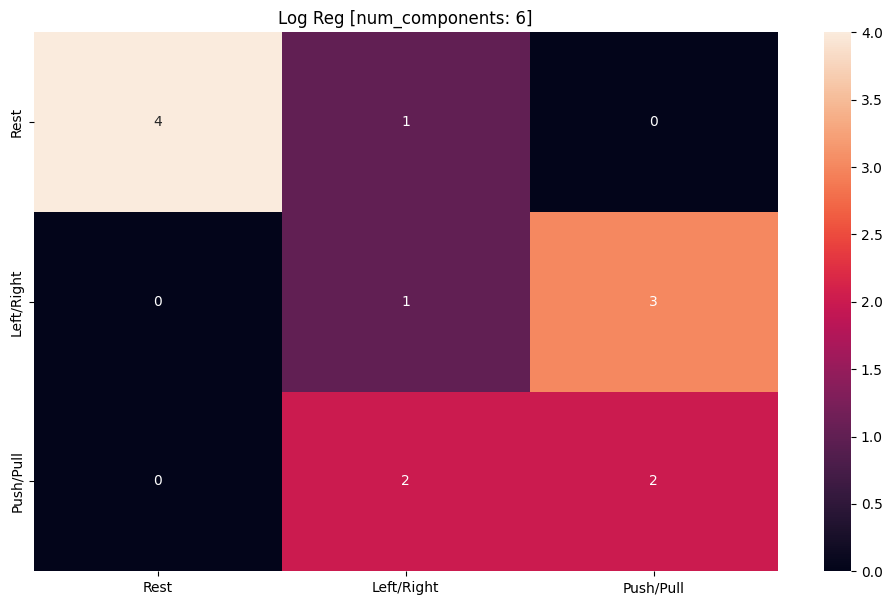

In [466]:
print(y_val)
print((y_pred))



cf_matrix = confusion_matrix(y_val, y_pred)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sns.heatmap(df_cm, annot=True)
plt.savefig('output.png')
plt.title(f'Log Reg [num_components: {num_components}]')

In [450]:
svm = SVC(kernel='rbf',random_state=16)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_val)

print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_val, y_pred)))

Model accuracy score with default hyperparameters: 0.6154


11     0
58     1
109    1
9      3
55     3
76     3
42     0
37     0
47     0
64     1
66     3
67     0
83     1
Name: Label, dtype: int64
[1 1 3 3 1 3 1 0 0 1 3 0 3]


Text(0.5, 1.0, 'SVM [num_components: 7]')

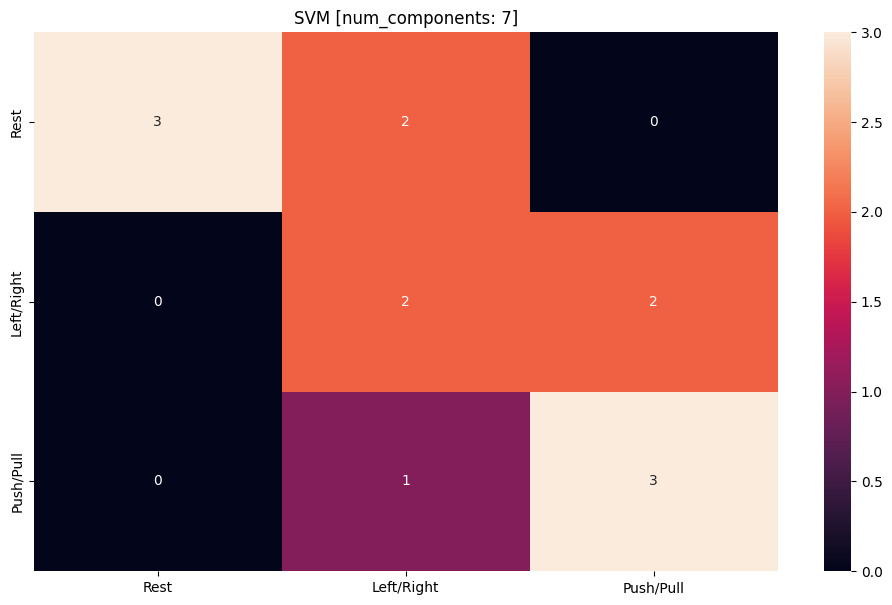

In [451]:
print(y_val)
print((y_pred))



cf_matrix = confusion_matrix(y_val, y_pred)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sns.heatmap(df_cm, annot=True)
plt.savefig('output.png')
plt.title(f'SVM [num_components: {num_components}]')

In [15]:
rf = RandomForestClassifier(random_state=16)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_val, y_pred)))

Model accuracy score with default hyperparameters: 0.6000


In [16]:
save_model(rf, filename='rf_LR_0.6000.pkl')

11     0
58     1
109    1
9      3
55     3
76     3
42     0
37     0
47     0
64     1
66     3
67     0
83     1
Name: Label, dtype: int64
[0 1 3 3 1 3 1 0 0 1 3 0 3]


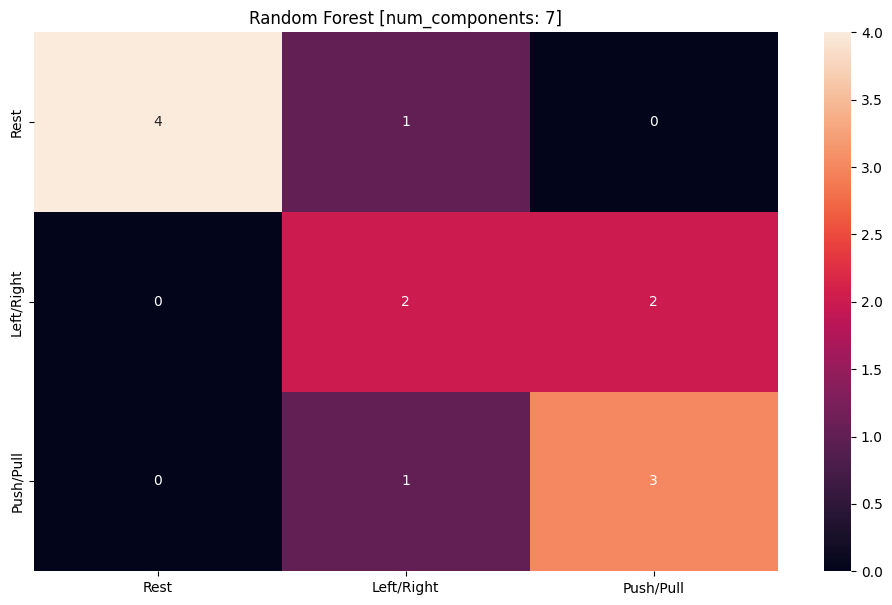

In [456]:
print(y_val)
print((y_pred))



cf_matrix = confusion_matrix(y_val, y_pred)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
plt.title(f'Random Forest [num_components: {num_components}]')
sns.heatmap(df_cm, annot=True)
plt.savefig('output.png')

# trying ensemble

In [493]:
from sklearn.ensemble import VotingClassifier
clr = LogisticRegression(random_state=16)
csv = SVC(kernel='rbf',random_state=16)
crf = RandomForestClassifier(random_state=16)




estimators = [
    ('lr',clr),
    ('svc',csv),
    ('rf',crf)
]

vc = VotingClassifier(estimators=estimators,voting='hard')

vc.fit(X_train, y_train)

y_pred =vc.predict(X_val)

print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_val, y_pred)))

Model accuracy score with default hyperparameters: 0.6923


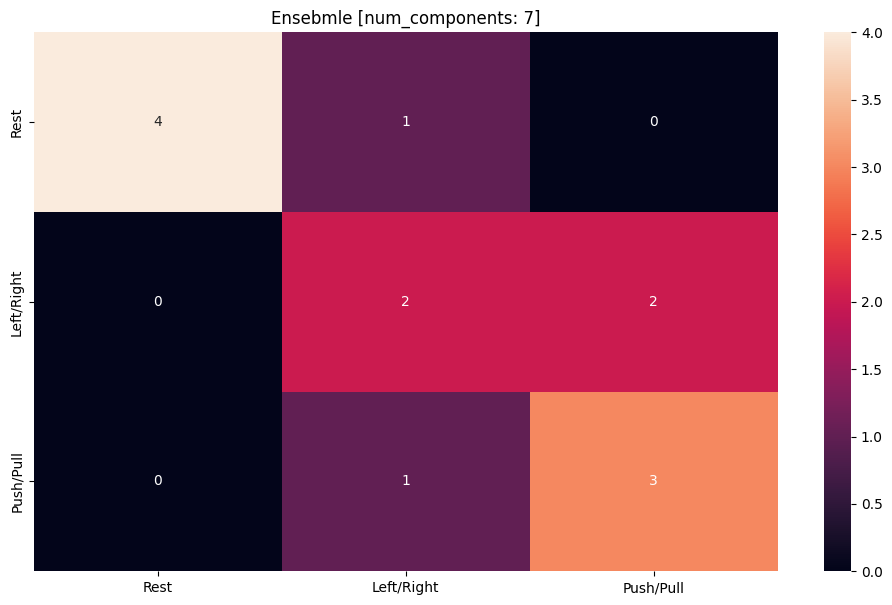

In [494]:
cf_matrix = confusion_matrix(y_val, y_pred)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
plt.title(f'Ensebmle [num_components: {num_components}]')
sns.heatmap(df_cm, annot=True)
plt.savefig('output.png')

# grid search on Log Reg

In [101]:
grid={"C":np.logspace(-3,3,7), "penalty":["l1","l2"]}

logreg=LogisticRegression(solver='lbfgs', max_iter=3500,random_state=16)
logreg_cv=GridSearchCV(logreg,grid,cv=5)
logreg_cv.fit(X_train,y_train)

print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stab

tuned hpyerparameters :(best parameters)  {'C': np.float64(1.0), 'penalty': 'l2'}
accuracy : 0.22000000000000003


C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Doing a Two Step Approach

In [ ]:
# three-class model
three_class_model = load_model('logreg_3CLASS_0.8462.pkl')


In [ ]:
# fn = filename
def load_classification_models(model_1_fn='logreg_7_3CLASS_0.8462.pkl', LR_model_fn='rf_4_LR_0.6000.pkl', PP_model_fn='logreg_6_PP_0.6000.pkl'):
    model_1 = load_model(model_1_fn)
    LR_model = load_model(LR_model_fn)
    PP_model = load_model(PP_model_fn)
    return model_1, LR_model, PP_model


def classify(input, model_1, LR_model, PP_model, pca1, pcaLR, pcaPP):

    three_output = model_1.predict(input)

    if three_output == 0:       # resting
        return 0
    
    elif three_output == 1:     # left/right
        LR_output = LR_model.predict(input)
        return LR_output
    
    elif three_output == 2:     # push/pull
        PP_output = PP_model.predict(input)
        return PP_output
    
    else:                       # ERROR
        return 0
 
    

In [ ]:
feature_df = pd.read_csv(f'../data/lzl_processed/feature_df.csv')
labels = feature_df['Label']